<a href="https://colab.research.google.com/github/Aneesha-Shr/Fiber-Image-Tracking/blob/Andrew/Fiber_Tracking_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Thu Apr  9 19:16:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
HOME = os.getcwd()
print("HOME:", HOME)

HOME: /content


In [3]:
!pip install git+https://github.com/ultralytics/ultralytics.git
!pip install git+https://github.com/facebookresearch/segment-anything-2.git
!git clone https://github.com/Aneesha-Shr/Fiber-Image-Tracking.git
!pip install -q supervision jupyter_bbox_widget

  Cloning https://github.com/ultralytics/ultralytics.git to /tmp/pip-req-build-kt90649n
  Running command git clone --filter=blob:none --quiet https://github.com/ultralytics/ultralytics.git /tmp/pip-req-build-kt90649n
  Resolved https://github.com/ultralytics/ultralytics.git to commit cf95678dc8852612ba44c59e0feb2d22a81a4965
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for ultralytics: filename=ultralytics-8.4.36-py3-none-any.whl size=1224301 sha256=baf31fbf130964f013bf93f8e44a6cac4ad2b6058fec4d91ce85fa508a4d1c0f
  Stored in directory: /tmp/pip-ephem-wheel-cache-g6dplr9e/wheels/07/0b/e8/a9b200841fd9259dec61e092d35594d5de8f3412e26e53cb4d
Successfully built ultralytics
  Cloning https://github.com/facebookresearch/segment-anything-2.git to /tmp/pip-req-build-jpfg134x
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything-2.git /tmp

In [ ]:
#from google.colab import files
#uploaded = files.upload()

In [ ]:
os.makedirs('/content/INPUT', exist_ok=True)
os.makedirs('/content/INTERMEDIATE', exist_ok=True)
os.makedirs('/content/OUTPUT', exist_ok=True)

In [ ]:
zip_filename = list(uploaded.keys())[0]
!unzip -o -j "{zip_filename}" -x "__MACOSX/*" ".*" -d /content/INPUT

NameError: name 'uploaded' is not defined

In [4]:
!mkdir -p {HOME}/checkpoints
!wget -q https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_tiny.pt -P {HOME}/checkpoints
!wget -q https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_small.pt -P {HOME}/checkpoints
!wget -q https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_base_plus.pt -P {HOME}/checkpoints
!wget -q https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_large.pt -P {HOME}/checkpoints

In [5]:
import cv2
import torch
import base64
import numpy as np
import supervision as sv

from pathlib import Path
from supervision.assets import download_assets, VideoAssets
from torchvision import transforms
from PIL import Image
from jupyter_bbox_widget import BBoxWidget
from ultralytics import YOLO
from sam2.build_sam import build_sam2_video_predictor

IS_COLAB = True
if IS_COLAB:
    from google.colab import output
    output.enable_custom_widget_manager()

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [6]:
torch.autocast(device_type="cuda", dtype=torch.bfloat16).__enter__()

if torch.cuda.get_device_properties(0).major >= 8:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

In [7]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CHECKPOINT = f"{HOME}/checkpoints/sam2_hiera_large.pt"
CONFIG = "sam2_hiera_l.yaml"
yolo_model = YOLO("/content/Fiber-Image-Tracking/fiberYOLOBB2.pt")
sam2_model = build_sam2_video_predictor(CONFIG, CHECKPOINT)

## Function to turn a folder of TIFF files into folder of JPEG files with frame skip

In [8]:
def tiff_to_jpeg(inputPath, outputPath, frameSkip):
  if not os.path.exists(outputPath):
    os.makedirs(outputPath)
  inputFiles = [img for img in os.listdir(inputPath) if img.endswith(".tif") or img.endswith(".tiff")]
  inputFiles.sort()
  for i, filename in enumerate(inputFiles):
    if i % frameSkip != 0:
            continue
    if filename.lower().endswith(('.tif', '.tiff')):
      imagePath = os.path.join(inputPath, filename)
      #make an empty jpeg with the same name as the input images
      newName = f"{i:05}.jpeg"
      interPath = os.path.join(outputPath, newName)
      try:
          image = Image.open(imagePath)
          if image.mode in ['I;16', 'I']:
            imageMod = np.array(image, dtype=np.uint16)
            imageMod = (imageMod / 256).astype(np.uint8)
            image = Image.fromarray(imageMod)
          image = image.convert('RGB')
          image.save(interPath, 'JPEG', quality=95)
      except Exception as image:
        print(f"Error converting '{filename}': {image}")


## Function to turn a folder of JPEG files into a MP4 with fps

In [9]:
def jpeg_to_mp4(inputPath, outputPath, fps):
  inputFiles = [img for img in os.listdir(inputPath) if img.endswith(".jpg") or img.endswith(".jpeg")]
  inputFiles.sort()
  if not inputFiles:
    print("No JPEG files found")
    return
  firstImagePath = os.path.join(inputPath, inputFiles[0])
  frame = cv2.imread(firstImagePath)
  height, width, _ = frame.shape
  fourcc = cv2.VideoWriter_fourcc(*'mp4v')
  video = cv2.VideoWriter(outputPath, fourcc, fps, (width, height))
  for i, inputFrame in enumerate(inputFiles):
    framePath = os.path.join(inputPath, inputFrame)
    frame = cv2.imread(framePath)
    if frame is None:
      print(f"Error reading frame {frame_path}, skipping it")
      continue
    video.write(frame)
  video.release()

# Sharpening Images

In [10]:
import os
from PIL import Image
import numpy as np
import cv2
import matplotlib.pylab as plt

plt.style.use('ggplot')

def sharpen_images(inputPath, outputPath):
  # Loop over all tendon images and SHARPEN

  # Create an output folder for the sharpened images to keep things organized

  if not os.path.isdir(inputPath):
      print(f"Error: Folder not found at '{inputPath}'")
  else:
      print(f"Searching for images in: {inputPath}")

      # Define acceptable image extensions
      image_extensions = ('.png', '.jpg', '.jpeg')

      for i, filename in enumerate(os.listdir(inputPath)):

          # path to the file
          full_file_path = os.path.join(inputPath, filename)

          # Filter to ensure we only process actual image files
          if os.path.isfile(full_file_path) and filename.lower().endswith(image_extensions):
              #print(f"Processing image {i+1}: {filename}")

              # Read the image into a NumPy array using OpenCV
              tendon_img = cv2.imread(full_file_path)

              # Check if image was read successfully (e.g., not a corrupted file)
              if tendon_img is None:
                  print(f"Warning: Could not read image file {filename}. Skipping.")
                  continue

              # Sharpening Kernel (this is correct)
              kernel_sharpening = np.array([[-1,-1,-1],
                                            [-1,9,-1],
                                            [-1,-1,-1]])

              # Apply the filter to the actual image data (tendon_img)
              sharpened = cv2.filter2D(tendon_img, -1, kernel_sharpening)

              # Save the sharpened image
              sharpPath = os.path.join(outputPath, f"{filename}")
              cv2.imwrite(sharpPath, sharpened)
              #print(f"Saved sharpened image to: {output_path}")

          elif not filename.startswith('.'): # Skip hidden files, but print a message for others
              print(f"Skipping non-image file: {filename}")

## Configure the Intermediate Folder

In [11]:
choice = 1

if choice == 1:
  INPUT_IMAGES = '/content/Fiber-Image-Tracking/IO Fiber Tracking/Input Folder'
  INTERMEDIATE_IMAGES = '/content/Fiber-Image-Tracking/IO Fiber Tracking/Intermediate Folder'
  OUTPUT = '/content/Fiber-Image-Tracking/IO Fiber Tracking/Output Folder'

elif choice == 2:
  INPUT_IMAGES = '/content/INPUT'
  INTERMEDIATE_IMAGES = '/content/INTERMEDIATE'
  OUTPUT = '/content/OUTPUT'

frameSkip = 10
fps = 5
SCALE_FACTOR = 1

tiff_to_jpeg(INPUT_IMAGES, INTERMEDIATE_IMAGES, frameSkip)
sharpen_images(INTERMEDIATE_IMAGES, INTERMEDIATE_IMAGES)
INTERMEDIATE_VIDEO = INPUT_IMAGES + '/Intermediate_Video.mp4'
jpeg_to_mp4(INTERMEDIATE_IMAGES, INTERMEDIATE_VIDEO, fps)
OUTPUT_VIDEO =  Path(HOME) / OUTPUT / '/Output_Video.mp4'
INTERMEDIATE_IMAGES_PATHS = sorted(sv.list_files_with_extensions((Path(HOME) / Path(INTERMEDIATE_IMAGES)).as_posix(), extensions=["jpg", "jpeg"]))

Searching for images in: /content/Fiber-Image-Tracking/IO Fiber Tracking/Intermediate Folder
Skipping non-image file: Sharpened JPEGS


In [12]:
inference_state = sam2_model.init_state(video_path=INTERMEDIATE_IMAGES)
sam2_model.reset_state(inference_state)

frame loading (JPEG): 100%|██████████| 70/70 [00:02<00:00, 25.02it/s]


In [13]:
FRAME_IDX = 0
FRAME_PATH = Path(INTERMEDIATE_IMAGES) / f"{FRAME_IDX:05d}.jpeg"
results = yolo_model(FRAME_PATH)
for bounds in results:
  boxes = bounds.boxes
  for i, box in enumerate(boxes):
    xyxy = box.xyxy[0].tolist()
    _, object_ids, mask_logits = sam2_model.add_new_points_or_box(
          inference_state=inference_state,
          frame_idx=FRAME_IDX,
          obj_id=i,
          box=xyxy,
          clear_old_points=True,
          normalize_coords=True,
    )


image 1/1 /content/Fiber-Image-Tracking/IO Fiber Tracking/Intermediate Folder/00000.jpeg: 640x640 46 Fibers, 20.2ms
Speed: 11.5ms preprocess, 20.2ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)



Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).


In [14]:
#def encode_image(filepath):
#    with open(filepath, 'rb') as f:
#        image_bytes = f.read()
#    encoded = str(base64.b64encode(image_bytes), 'utf-8')
#    return "data:image/jpg;base64,"+encoded

In [15]:
#OBJECTS = ['fiber-1', 'fiber-2', 'fiber-3']

In [16]:
#FRAME_IDX = 0
#FRAME_PATH = Path(INTERMEDIATE_IMAGES) / f"{FRAME_IDX:05d}.jpeg"
#widget = BBoxWidget(classes=OBJECTS)
#widget.image = encode_image(FRAME_PATH)
#widget

In [17]:
#default_box = [
#    {'x': 705, 'y': 302, 'width': 0, 'height': 0, 'label': 'fiber-1'},
#    {'x': 587, 'y': 300, 'width': 0, 'height': 0, 'label': 'fiber-2'},
#    {'x': 753, 'y': 267, 'width': 0, 'height': 0, 'label': 'fiber-3'}
#]

#boxes = widget.bboxes if widget.bboxes else default_box

#for object_id, label in enumerate(OBJECTS, start=1):
#    boxes = [box for box in widget.bboxes if box['label'] == label]

#    if len(boxes) == 0:
#        continue

#    points = np.array([
#        [
#            box['x'],
#            box['y']
#        ] for box in boxes
#    ], dtype=np.float32)
#    labels = np.ones(len(points))

#    _, object_ids, mask_logits = sam2_model.add_new_points(
#        inference_state=inference_state,
#        frame_idx=FRAME_IDX,
#        obj_id=object_id,
#        points=points,
#        labels=labels,
#    )

In [18]:
video_info = sv.VideoInfo.from_video_path(INTERMEDIATE_VIDEO)
video_info.width = int(video_info.width * SCALE_FACTOR)
video_info.height = int(video_info.height * SCALE_FACTOR)

COLORS = ['#FF1493', '#00BFFF', '#FF6347', '#FFD700']
mask_annotator = sv.MaskAnnotator(
    color=sv.ColorPalette.from_hex(COLORS),
    color_lookup=sv.ColorLookup.CLASS)

OUTPUT_IMAGES = Path(HOME) / OUTPUT
frame_sample = []

#list to hold masks for 3D visualization
mask_list = []

with sv.VideoSink(OUTPUT_VIDEO.as_posix(), video_info=video_info) as sink:
    for frame_idx, object_ids, mask_logits in sam2_model.propagate_in_video(inference_state):
        frame_path = INTERMEDIATE_IMAGES_PATHS[frame_idx]
        frame = cv2.imread(frame_path)
        masks = (mask_logits > 0.0).cpu().numpy()
        masks = np.squeeze(masks).astype(bool)

        #Added section for 3D visualization
        current_mask = (mask_logits > 0.0).cpu().numpy()
        current_mask = np.squeeze(current_mask)
        if current_mask.ndim == 3:
            combined_mask = np.any(current_mask, axis=0)
        else:
            combined_mask = current_mask
        mask_uint8 = (combined_mask.astype(np.uint8) * 255)
        mask_list.append(mask_uint8)

        detections = sv.Detections(
            xyxy=sv.mask_to_xyxy(masks=masks),
            mask=masks,
            class_id=np.array(object_ids)
        )

        annotated_frame = mask_annotator.annotate(scene=frame.copy(), detections=detections)
        annotated_frame_path = OUTPUT_IMAGES / f"Annotated{frame_idx:05d}.jpeg"
        cv2.imwrite(annotated_frame_path.as_posix(), annotated_frame)

        sink.write_frame(annotated_frame)

        if frame_idx % video_info.fps == 0:
            frame_sample.append(annotated_frame)

masks = mask_list
print(f"Successfully collected {len(masks)} masks for 3D generation.")
masks_3d_array = np.array(masks)
np.savez_compressed('masks_3d_data.npz', masks_3d_array)

propagate in video: 100%|██████████| 70/70 [14:25<00:00, 12.36s/it]

Successfully collected 70 masks for 3D generation.


# Sanity check: what fibers are getting tracked

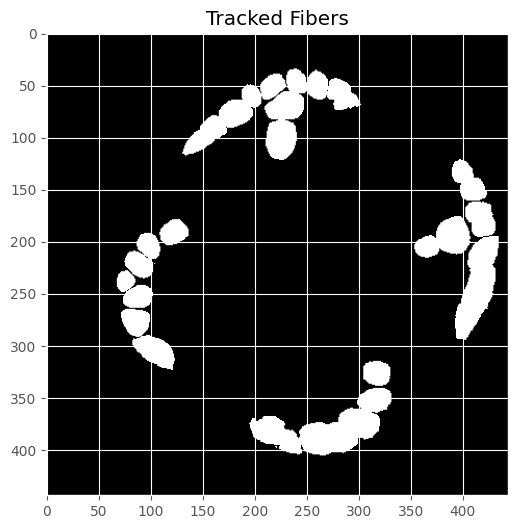

Computer sees 11 distinct objects in this mask.


In [19]:
#Check that masks are created properly
import matplotlib.pyplot as plt
import cv2 as cv

# Check the first mask in your list
if 'masks' in globals() and len(masks) > 0:
    test_mask = masks[0]

    plt.figure(figsize=(6,6))
    plt.imshow(test_mask, cmap='gray')
    plt.title(f"Tracked Fibers")
    plt.show()

    # Count separate blobs mathematically
    num_labels, labels = cv.connectedComponents(test_mask.astype('uint8') * 255)
    print(f"Computer sees {num_labels - 1} distinct objects in this mask.")
else:
    print("Error: 'masks' list is empty or undefined.")

#print(mask[0])

14


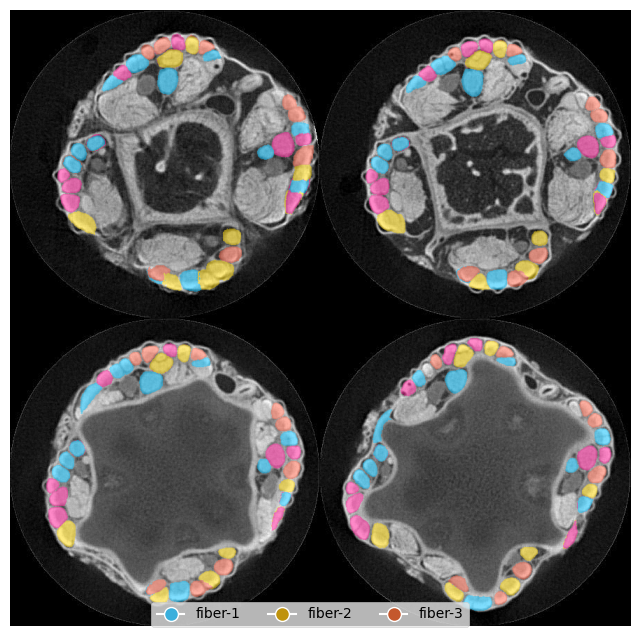

In [20]:
import matplotlib.pyplot as plt
import numpy as np

print(len(frame_sample))
image_arrays = [
    frame_sample[0],
    frame_sample[3],
    frame_sample[6],
    frame_sample[9]
]

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

plt.subplots_adjust(wspace=0, hspace=0)

for i, ax in enumerate(axes.flat):
    if i < len(image_arrays):
        img_array = image_arrays[i]
        image_rgb = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)
        ax.imshow(image_rgb, origin='upper', aspect='auto')
        ax.axis('off')

legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='fiber-1', markerfacecolor='#3aafdc', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='fiber-2', markerfacecolor='#bf930d', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='fiber-3', markerfacecolor='#c4582d', markersize=10),
]

fig.legend(handles=legend_elements, loc='lower center', ncol=3, bbox_to_anchor=(0.5, 0.1), bbox_transform=fig.transFigure)

plt.savefig( OUTPUT + '/Sample_Output.png', bbox_inches='tight', pad_inches=0.01)
plt.show()


In [21]:
#This code creates individual bounding boxes out of the masks so maybe we could use this
#to split the fibers up from the large mask and then color each individually in the 3D?
targets = {}

for frame_idx, object_ids, mask_logits in sam2_model.propagate_in_video(inference_state):
    print(frame_idx, object_ids)
    masks = (mask_logits > 0.0).cpu().numpy()
    masks = np.squeeze(masks).astype(bool)
    detections = sv.Detections(
        xyxy=sv.mask_to_xyxy(masks=masks),
        mask=masks,
        class_id=np.array(object_ids)
    )
    for i, obj_id in enumerate(object_ids):
        if obj_id not in targets:
            targets[obj_id] = []
        targets[obj_id].append(detections.xyxy[i])

propagate in video:   0%|          | 0/70 [00:00<?, ?it/s]

0 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45]


propagate in video:   3%|▎         | 2/70 [00:05<02:53,  2.55s/it]

1 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45]


propagate in video:   4%|▍         | 3/70 [00:11<04:33,  4.08s/it]

...

propagate in video:  97%|█████████▋| 68/70 [14:02<00:25, 13.00s/it]

68 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45]


propagate in video:  99%|█████████▊| 69/70 [14:15<00:13, 13.02s/it]

69 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45]


propagate in video: 100%|██████████| 70/70 [14:28<00:00, 12.41s/it]


In [23]:
from google.colab.patches import cv2_imshow

frame = cv2.imread( INTERMEDIATE_IMAGES + '/00000.jpeg')

if frame is not None and len(target_0) > 0:
    x1, y1, x2, y2 = target_0[0].astype(int)
    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2) # Draw green rectangle
    cv2_imshow(frame)  # Display the frame
else:
    print("Error: Could not read frame or target_0 is empty.")


NameError: name 'target_0' is not defined

In [ ]:
center_target_0 = [(int((target_0_i[0] + target_0_i[2]) / 2), int((target_0_i[1] + target_0_i[3]) / 2)) for target_0_i in target_0]
center_target_1 = [(int((target_1_i[0] + target_1_i[2]) / 2), int((target_1_i[1] + target_1_i[3]) / 2)) for target_1_i in target_1]
center_target_2 = [(int((target_2_i[0] + target_2_i[2]) / 2), int((target_2_i[1] + target_2_i[3]) / 2)) for target_2_i in target_2]

In [ ]:
# Sample sequence of locations (x, y)
locations = center_target_0

background_image = cv2.imread( INTERMEDIATE_IMAGES + '/00000.jpeg')

cv2.circle(background_image, locations[0], radius=10, color=(255, 0, 0), thickness=-1)

for i in range(len(locations) - 1):
    start_point = locations[i]
    end_point = locations[i + 1]
    cv2.line(background_image, start_point, end_point, (255, 0, 0), thickness=1)  # Blue line
    cv2.circle(background_image, start_point, radius=2, color=(0, 0, 255), thickness=-1)  # Red circle at points

cv2.circle(background_image, locations[-1], radius=10, color=(0, 255, 0), thickness=-1)

cv2_imshow(background_image)


# Save the result if needed
# cv2.imwrite("trace_of_movement.png", background_image)

## 3D Processing

In [24]:
import numpy as np
import cv2
import plotly.graph_objects as go
import os

def createPointCloud(filename, arr):
    with open(filename, 'w') as file:
        file.write("ply\n")
        file.write("format ascii 1.0\n")
        num_verts = arr.shape[0]
        file.write(f"element vertex {num_verts}\n")
        file.write("property float32 x\n")
        file.write("property float32 y\n")
        file.write("property float32 z\n")
        file.write("end_header\n")

        for i, point in enumerate(arr):
            #if i % 1000 == 0:
            #    print(f"Writing point {i} of {len(arr)}")
            # Write x y z
            file.write(f"{point[0]} {point[1]} {point[2]}\n")

def addPoints(mask, points_list, depth):
    # Find indices where mask is 255 (white)
    y_indices, x_indices = np.where(mask == 255)

    # Zip them together to get (x, y) pairs
    for x, y in zip(x_indices, y_indices):
        points_list.append([x, y, depth])

#used to find initial file size to create x and y axis
def getSize(inputPath):
  image_extensions = ('.png', '.jpg', '.jpeg')
  img = cv.imread(inputPath)
  print(img.shape)
  x,y = img.shape[:2]
  print(f"fileSize: {x},{y}")
  return x,y

def main():
    # Load the data for masks
    try:
        data = np.load('masks_3d_data.npz')
        print("Keys inside file:", data.files)
        # arr_0 is default
        if 'masks' in data:
            masks = data['masks']
        else:
            masks = data['arr_0']

    except FileNotFoundError:
        print("Error: 'masks_3d_data.npz' not found. Upload it first!")
        return None

    # Tweakables
    slice_thickness = 0.5 #This does NOT adjust distance between points
    xy_scale = 1
    depth = 0
    points = []

    print(f"Processing {len(masks)} frames...")

    # Process frames
    for index in range(1, len(masks) - 1):
        if index % 10 == 0:
            print(f"Processing frame {index}/{len(masks)}")

        prev = masks[index - 1]
        curr = masks[index]
        after = masks[index + 1]

        # Find pixels in current frame that weren't in previous (new edges)
        prev_mask = np.zeros_like(curr)
        mask_indices = (prev == 0)
        prev_mask[mask_indices] = curr[mask_indices]
        addPoints(prev_mask, points, depth)

        # Find pixels in current that aren't in next
        next_mask = np.zeros_like(curr)
        mask_indices_after = (after == 0)
        next_mask[mask_indices_after] = curr[mask_indices_after]
        addPoints(next_mask, points, depth)

        # Contour points
        curr_uint8 = curr.astype('uint8')
        # make sure it's in 0-255 range
        if curr_uint8.max() <= 1:
            curr_uint8 *= 255

        contours, _ = cv2.findContours(curr_uint8, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
        for con in contours:
            for point in con:
                p = point[0]
                points.append([p[0], p[1], depth])

        depth += slice_thickness

    # Post-process points
    points = np.array(points, dtype=np.float32)

    # Scale X and Y
    points[:, 0] *= xy_scale
    points[:, 1] *= xy_scale

    # Remove duplicates
    print("Removing duplicates...")
    points = np.unique(points, axis=0)
    print(f"Final Point Cloud Shape: {points.shape}")

    # Save to file
    createPointCloud("test.ply", points)

    return points

if __name__ == "__main__":
    points = main()
    # get axis scale
    if choice == 1:
      inputPath = '/content/Fiber-Image-Tracking/Sharpened JPEGS/sharpened_00005.jpeg'
    elif choice == 2:
      inputPath = '/content/INTERMEDIATE/00000.jpeg'
    width,height = getSize(inputPath)
    # Only run plotting if points were successfully returned
    if points is not None and len(points) > 0:

        # Define limits for plot based on actual data
        max_x = np.max(points[:, 0])
        max_y = np.max(points[:, 1])

        print("Generating Plot...")
        fig = go.Figure(data=[go.Scatter3d(
            x=points[:, 0],
            y=points[:, 1],
            z=points[:, 2],
            mode='markers',
            marker=dict(
                size=2,
                color=points[:, 2],
                colorscale='Viridis',
                opacity=0.8
            )
        )])

        fig.update_layout(
            scene=dict(
                xaxis=dict(range=[0, width], title="Width"),
                yaxis=dict(range=[0, height], title="Height"),
                zaxis=dict(title="Depth"),
                #aspectmode='data'
                aspectmode='manual',
                aspectratio=dict(x=1, y=1, z=0.5)
                #Z affects distance between points (it's about the scale so must be manually adjusted for more pictures for now)
            ),
            margin=dict(l=0, r=0, b=0, t=0)
        )

        fig.show()
    else:
        print("No points generated. Check your data.")

Keys inside file: ['arr_0']
Processing 70 frames...
Processing frame 10/70
Processing frame 20/70
Processing frame 30/70
Processing frame 40/70
Processing frame 50/70
Processing frame 60/70
Removing duplicates...
Final Point Cloud Shape: (189357, 3)
(444, 444, 3)
fileSize: 444,444
Generating Plot...


In [36]:
import numpy as np
import cv2
import plotly.graph_objects as go
import os

def createPointCloud(filename, arr):
    with open(filename, 'w') as file:
        file.write("ply\n")
        file.write("format ascii 1.0\n")
        num_verts = arr.shape[0]
        file.write(f"element vertex {num_verts}\n")
        file.write("property float32 x\n")
        file.write("property float32 y\n")
        file.write("property float32 z\n")
        file.write("property int32 blob_id\n")
        file.write("end_header\n")

        for i, point in enumerate(arr):
            file.write(f"{point[0]} {point[1]} {point[2]} {int(point[3])}\n")

def addPoints(mask, points_list, depth, blob_id):
    y_indices, x_indices = np.where(mask == 255)
    for x, y in zip(x_indices, y_indices):
        points_list.append([x, y, depth, blob_id])

def getSize(inputPath):
    img = cv2.imread(inputPath)
    print(img.shape)
    x, y = img.shape[:2]
    print(f"fileSize: {x},{y}")
    return x, y

def main(targets):
    # targets: dict of obj_id -> [bbox per frame]
    # built from SAM2 propagation block below

    try:
        data = np.load('masks_3d_data.npz')
        print("Keys inside file:", data.files)
        if 'masks' in data:
            masks = data['masks']
        else:
            masks = data['arr_0']

    except FileNotFoundError:
        print("Error: 'masks_3d_data.npz' not found. Upload it first!")
        return None

    # Tweakables
    slice_thickness = 0.5
    xy_scale = 1
    depth = 0
    points = []

    print(f"Processing {len(masks)} frames across {len(targets)} fibers...")

    for index in range(1, len(masks) - 1):
        if index % 10 == 0:
            print(f"Processing frame {index}/{len(masks)}")

        prev  = masks[index - 1]
        curr  = masks[index]
        after = masks[index + 1]

        curr_uint8 = curr.astype('uint8')
        if curr_uint8.max() <= 1:
            curr_uint8 *= 255

        prev_uint8 = prev.astype('uint8')
        if prev_uint8.max() <= 1:
            prev_uint8 *= 255

        after_uint8 = after.astype('uint8')
        if after_uint8.max() <= 1:
            after_uint8 *= 255

        # Process each SAM2-tracked fiber using its bounding box
        for obj_idx, (obj_id, bbox_list) in enumerate(targets.items()):

            # Skip if this frame is out of range for this fiber
            if index >= len(bbox_list):
                continue

            x1, y1, x2, y2 = bbox_list[index].astype(int)

            # Clamp bbox to image bounds
            x1 = max(x1, 0)
            y1 = max(y1, 0)
            x2 = min(x2, curr_uint8.shape[1])
            y2 = min(y2, curr_uint8.shape[0])

            # Isolate this fiber using its bounding box region
            blob_mask = np.zeros_like(curr_uint8)
            blob_mask[y1:y2, x1:x2] = curr_uint8[y1:y2, x1:x2]

            # Edge points vs previous frame
            prev_mask = np.zeros_like(curr_uint8)
            prev_mask[(prev_uint8 == 0) & (blob_mask == 255)] = 255
            addPoints(prev_mask, points, depth, obj_idx)

            # Edge points vs next frame
            next_mask = np.zeros_like(curr_uint8)
            next_mask[(after_uint8 == 0) & (blob_mask == 255)] = 255
            addPoints(next_mask, points, depth, obj_idx)

            # Contour points
            contours, _ = cv2.findContours(blob_mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
            for con in contours:
                for point in con:
                    p = point[0]
                    points.append([p[0], p[1], depth, obj_idx])

        depth += slice_thickness

    # Post-process points
    points = np.array(points, dtype=np.float32)
    if len(points) == 0:
        print("No points generated. Check your data.")
        return None

    points[:, 0] *= xy_scale
    points[:, 1] *= xy_scale

    print("Removing duplicates...")
    points = np.unique(points, axis=0)
    print(f"Final Point Cloud Shape: {points.shape}")
    print(f"Unique fibers: {int(np.max(points[:, 3])) + 1}")

    createPointCloud("test.ply", points)

    return points


if __name__ == "__main__":

    points = main(targets)

    inputPath = '/content/Fiber-Image-Tracking/Sharpened JPEGS/sharpened_00005.jpeg'
    width, height = getSize(inputPath)

    if points is not None and len(points) > 0:
        print("Generating Plot...")

        fig = go.Figure()
        for blob_id in np.unique(points[:, 3]).astype(int):
            blob_pts = points[points[:, 3] == blob_id]
            fig.add_trace(go.Scatter3d(
                x=blob_pts[:, 0],
                y=blob_pts[:, 1],
                z=blob_pts[:, 2],
                mode='markers',
                name=f"Fiber {blob_id}",
                marker=dict(size=2, opacity=0.8)
            ))

        fig.update_layout(
            scene=dict(
                xaxis=dict(range=[0, width],  title="Width"),
                yaxis=dict(range=[0, height], title="Height"),
                zaxis=dict(title="Depth"),
                aspectmode='manual',
                aspectratio=dict(x=1, y=1, z=0.5)
            ),
            margin=dict(l=0, r=0, b=0, t=0),
            legend=dict(title="Fibers", itemsizing='constant')
        )

        fig.show()
    else:
        print("No points generated. Check your data.")

Keys inside file: ['arr_0']
Processing 70 frames across 46 fibers...
Processing frame 10/70
Processing frame 20/70
Processing frame 30/70
Processing frame 40/70
Processing frame 50/70
Processing frame 60/70
Removing duplicates...
Final Point Cloud Shape: (306504, 4)
Unique fibers: 46
(444, 444, 3)
fileSize: 444,444
Generating Plot...


In [26]:
!pip install open3d

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 58.1 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.7.1
    Uninstalling ipywidgets-7.7.1:
      Successfully uninstalled ipywidgets-7.7.1


In [41]:
import numpy as np
import open3d as o3d

all_triangles = []
all_vertices = []
all_colors = []
vertex_offset = 0

# Generate a distinct color per blob
unique_blobs = np.unique(points[:, 3]).astype(int)
num_blobs = len(unique_blobs)

import colorsys
def blob_color(idx, total):
    r, g, b = colorsys.hsv_to_rgb(idx / max(total, 1), 0.85, 0.95)
    return [r, g, b]

for blob_id in unique_blobs:
    blob_pts = points[points[:, 3] == blob_id][:, :3]

    if len(blob_pts) < 4:
        print(f"Blob {blob_id}: not enough points, skipping")
        continue

    print(f"Blob {blob_id}: {len(blob_pts)} points")

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(blob_pts)

    # Estimate normals
    pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=5, max_nn=30))
    pcd.orient_normals_consistent_tangent_plane(k=15)

    # Ball pivoting (better for thin elongated fibers)
    avg_dist = dists[:, 1].mean()
    print(avg_dist)
    radii = [avg_dist, avg_dist * 2, avg_dist * 4]
    mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_ball_pivoting(
        pcd, o3d.utility.DoubleVector(radii)
    )

    # Skip if mesh is empty
    if len(mesh.vertices) == 0 or len(mesh.triangles) == 0:
        print(f"Blob {blob_id}: mesh is empty, trying Poisson fallback...")
        mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(pcd, depth=9)
        densities = np.asarray(densities)
        mesh.remove_vertices_by_mask(densities < np.percentile(densities, 5))

    if len(mesh.vertices) == 0:
        print(f"Blob {blob_id}: still empty, skipping")
        continue

    verts = np.asarray(mesh.vertices)
    tris  = np.asarray(mesh.triangles) + vertex_offset
    color = blob_color(blob_id, num_blobs)

    all_vertices.append(verts)
    all_triangles.append(tris)
    all_colors.append(np.tile(color, (len(verts), 1)))
    vertex_offset += len(verts)

    print(f"Blob {blob_id}: {len(verts)} vertices, {len(tris)} faces")

if len(all_vertices) == 0:
    print("No meshes generated. Check your points array.")
else:
    all_vertices  = np.vstack(all_vertices)
    all_triangles = np.vstack(all_triangles)
    all_colors    = np.vstack(all_colors)

    # Save as PLY with per-vertex color
    with open("Triangle_mesh.ply", 'w') as f:
        f.write("ply\n")
        f.write("format ascii 1.0\n")
        f.write(f"element vertex {len(all_vertices)}\n")
        f.write("property float x\n")
        f.write("property float y\n")
        f.write("property float z\n")
        f.write("property uchar red\n")
        f.write("property uchar green\n")
        f.write("property uchar blue\n")
        f.write(f"element face {len(all_triangles)}\n")
        f.write("property list uchar int vertex_indices\n")
        f.write("end_header\n")
        for v, c in zip(all_vertices, all_colors):
            r, g, b = int(c[0]*255), int(c[1]*255), int(c[2]*255)
            f.write(f"{v[0]} {v[1]} {v[2]} {r} {g} {b}\n")
        for t in all_triangles:
            f.write(f"3 {t[0]} {t[1]} {t[2]}\n")

    print(f"\nSaved test_mesh.ply")
    print(f"Total vertices : {len(all_vertices)}")
    print(f"Total faces    : {len(all_triangles)}")

Blob 0: 8086 points
0.6427500472091409
Blob 0: 8086 vertices, 8110 faces
Blob 1: 8353 points
0.6427500472091409
Blob 1: 8353 vertices, 8577 faces
Blob 2: 5167 points
0.6427500472091409
Blob 2: 5167 vertices, 5634 faces
Blob 3: 9223 points
0.6427500472091409
Blob 3: 9223 vertices, 8954 faces
Blob 4: 5503 points
0.6427500472091409
Blob 4: 5503 vertices, 5201 faces
Blob 5: 6314 points
0.6427500472091409
Blob 5: 6314 vertices, 6131 faces
Blob 6: 5636 points
0.6427500472091409
Blob 6: 5636 vertices, 5182 faces
Blob 7: 5511 points
0.6427500472091409
Blob 7: 5511 vertices, 5246 faces
Blob 8: 5182 points
0.6427500472091409
Blob 8: 5182 vertices, 4930 faces
Blob 9: 8423 points
0.6427500472091409
Blob 9: 8423 vertices, 9300 faces
Blob 10: 4291 points
0.6427500472091409
Blob 10: 4291 vertices, 4689 faces
Blob 11: 6596 points
0.6427500472091409
Blob 11: 6596 vertices, 6215 faces
Blob 12: 6514 points
0.6427500472091409
Blob 12: 6514 vertices, 6019 faces
Blob 13: 7028 points
0.6427500472091409
Blob 

In [28]:
from scipy.spatial import KDTree
tree = KDTree(blob_pts)
dists, _ = tree.query(blob_pts, k=2)
print(f"Avg nearest neighbor distance: {dists[:, 1].mean():.2f}")

Avg nearest neighbor distance: 0.64


In [44]:
import numpy as np
import colorsys
from skimage import measure
from scipy.ndimage import binary_dilation

all_triangles = []
all_vertices  = []
all_colors    = []
vertex_offset = 0

unique_blobs = np.unique(points[:, 3]).astype(int)
num_blobs    = len(unique_blobs)

def blob_color(idx, total):
    r, g, b = colorsys.hsv_to_rgb(idx / max(total, 1), 0.85, 0.95)
    return [r, g, b]

for blob_id in unique_blobs:
    blob_pts = points[points[:, 3] == blob_id][:, :3].astype(int)

    if len(blob_pts) < 4:
        print(f"Blob {blob_id}: not enough points, skipping")
        continue

    print(f"Blob {blob_id}: {len(blob_pts)} points")

    # Build 3D voxel grid
    # Offset so minimum is at 0 to keep grid small
    offset = blob_pts.min(axis=0)
    shifted = blob_pts - offset

    grid = np.zeros((shifted[:, 0].max() + 3,
                     shifted[:, 1].max() + 3,
                     shifted[:, 2].max() + 3), dtype=np.uint8)
    grid[shifted[:, 0], shifted[:, 1], shifted[:, 2]] = 1

    # Dilate to thicken fibers and close gaps
    # Increase iterations if you still have holes
    grid = binary_dilation(grid, iterations=1).astype(np.uint8)

    # Run marching cubes
    try:
        verts, faces, normals, _ = measure.marching_cubes(grid, level=0.5)
    except Exception as e:
        print(f"Blob {blob_id}: marching cubes failed — {e}")
        continue

    if len(verts) == 0 or len(faces) == 0:
        print(f"Blob {blob_id}: empty mesh, skipping")
        continue

    # Shift vertices back to original coordinate space
    verts += offset

    color = blob_color(blob_id, num_blobs)
    faces_offset = faces + vertex_offset

    all_vertices.append(verts)
    all_triangles.append(faces_offset)
    all_colors.append(np.tile(color, (len(verts), 1)))
    vertex_offset += len(verts)

    print(f"Blob {blob_id}: {len(verts)} vertices, {len(faces)} faces")

if len(all_vertices) == 0:
    print("No meshes generated. Check your points array.")
else:
    all_vertices  = np.vstack(all_vertices)
    all_triangles = np.vstack(all_triangles)
    all_colors    = np.vstack(all_colors)

    # Save as PLY with per-vertex color
    with open("Cube_mesh.ply", 'w') as f:
        f.write("ply\n")
        f.write("format ascii 1.0\n")
        f.write(f"element vertex {len(all_vertices)}\n")
        f.write("property float x\n")
        f.write("property float y\n")
        f.write("property float z\n")
        f.write("property uchar red\n")
        f.write("property uchar green\n")
        f.write("property uchar blue\n")
        f.write(f"element face {len(all_triangles)}\n")
        f.write("property list uchar int vertex_indices\n")
        f.write("end_header\n")
        for v, c in zip(all_vertices, all_colors):
            r, g, b = int(c[0]*255), int(c[1]*255), int(c[2]*255)
            f.write(f"{v[0]} {v[1]} {v[2]} {r} {g} {b}\n")
        for t in all_triangles:
            f.write(f"3 {t[0]} {t[1]} {t[2]}\n")

    print(f"\nSaved cube_mesh.ply")
    print(f"Total vertices : {len(all_vertices)}")
    print(f"Total faces    : {len(all_triangles)}")

Blob 0: 8086 points
Blob 0: 17144 vertices, 33914 faces
Blob 1: 8353 points
Blob 1: 19287 vertices, 38192 faces
Blob 2: 5167 points
Blob 2: 10911 vertices, 21618 faces
Blob 3: 9223 points
Blob 3: 18412 vertices, 36470 faces
Blob 4: 5503 points
Blob 4: 10188 vertices, 20056 faces
Blob 5: 6314 points
Blob 5: 11844 vertices, 23352 faces
Blob 6: 5636 points
Blob 6: 11729 vertices, 23162 faces
Blob 7: 5511 points
Blob 7: 10987 vertices, 21672 faces
Blob 8: 5182 points
Blob 8: 9581 vertices, 18970 faces
Blob 9: 8423 points
Blob 9: 18985 vertices, 37608 faces
Blob 10: 4291 points
Blob 10: 9586 vertices, 18956 faces
Blob 11: 6596 points
Blob 11: 15770 vertices, 31276 faces
Blob 12: 6514 points
Blob 12: 13687 vertices, 27088 faces
Blob 13: 7028 points
Blob 13: 14582 vertices, 28846 faces
Blob 14: 5389 points
Blob 14: 11430 vertices, 22596 faces
Blob 15: 8232 points
Blob 15: 16167 vertices, 31886 faces
Blob 16: 6615 points
Blob 16: 13446 vertices, 26702 faces
Blob 17: 5197 points
Blob 17: 12224 

Add faces to test.ply